## What is Scaffold Analysis?

Scaffold analysis is the process of extracting molecular scaffolds from a collection of compounds and studying their frequency, diversity, and relationships.

Rather than focusing on complete molecules, scaffold analysis focuses on the underlying structural frameworks shared by related compounds.

## Chemist's Perspective

Medicinal chemists rarely ask:

"How many molecules do I have?"

Instead, they ask:

- How many unique scaffolds are present?
- Which scaffold is most common?
- Which scaffold produces the highest biological activity?
- Which scaffold should be optimized further?

Scaffold analysis answers these questions.

Scaffold analysis helps to:

- Organize chemical libraries
- Measure scaffold diversity
- Identify dominant scaffold families
- Guide lead optimization
- Prioritize compounds
- Design new screening libraries

# Example: Scaffold Analysis of Small Library

In [1]:
# Create a Drug Library
from rdkit import Chem
import pandas as pd

drugs = {
    "Aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "Paracetamol": "CC(=O)NC1=CC=C(C=C1)O",
    "Ibuprofen": "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O",
    "Naproxen": "COc1ccc2cc([C@@H](C)C(=O)O)ccc2c1",
    "Diclofenac": "O=C(O)Cc1ccccc1Nc2c(Cl)cccc2Cl",
    "Celecoxib": "CC1=CC(C)=NN1c2ccc(S(N)(=O)=O)cc2",
    "Caffeine": "Cn1cnc2n(C)c(=O)n(C)c(=O)c12",
    "Benzocaine": "CCOC(=O)c1ccc(N)cc1"
}

df = pd.DataFrame(
    drugs.items(),
    columns=["Drug","SMILES"]
)

df

,Drug,SMILES
0,Aspirin,CC(=O)Oc1ccccc1C(=O)O
1,Paracetamol,CC(=O)NC1=CC=C(C=C1)O
2,Ibuprofen,CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O
3,Naproxen,COc1ccc2cc([C@@H](C)C(=O)O)ccc2c1
4,Diclofenac,O=C(O)Cc1ccccc1Nc2c(Cl)cccc2Cl
5,Celecoxib,CC1=CC(C)=NN1c2ccc(S(N)(=O)=O)cc2
6,Caffeine,Cn1cnc2n(C)c(=O)n(C)c(=O)c12
7,Benzocaine,CCOC(=O)c1ccc(N)cc1


In [2]:
# Extract Murcko Scaffold
from rdkit.Chem.Scaffolds import MurckoScaffold

scaffolds = []

for smiles in df["SMILES"]:

    mol = Chem.MolFromSmiles(smiles)

    scaffold = MurckoScaffold.GetScaffoldForMol(mol)

    scaffolds.append(Chem.MolToSmiles(scaffold))

df["Scaffold"] = scaffolds

df

,Drug,SMILES,Scaffold
0,Aspirin,CC(=O)Oc1ccccc1C(=O)O,c1ccccc1
1,Paracetamol,CC(=O)NC1=CC=C(C=C1)O,c1ccccc1
2,Ibuprofen,CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O,c1ccccc1
3,Naproxen,COc1ccc2cc([C@@H](C)C(=O)O)ccc2c1,c1ccc2ccccc2c1
4,Diclofenac,O=C(O)Cc1ccccc1Nc2c(Cl)cccc2Cl,c1ccc(Nc2ccccc2)cc1
5,Celecoxib,CC1=CC(C)=NN1c2ccc(S(N)(=O)=O)cc2,c1ccc(-n2cccn2)cc1
6,Caffeine,Cn1cnc2n(C)c(=O)n(C)c(=O)c12,O=c1[nH]c(=O)c2[nH]cnc2[nH]1
7,Benzocaine,CCOC(=O)c1ccc(N)cc1,c1ccccc1


In [3]:
# Count Scaffold Frequency
scaffold_counts = (
    df["Scaffold"]
    .value_counts()
    .reset_index()
)

scaffold_counts.columns = ["Scaffold","Frequency"]

scaffold_counts

,Scaffold,Frequency
0,c1ccccc1,4
1,c1ccc2ccccc2c1,1
2,c1ccc(Nc2ccccc2)cc1,1
3,c1ccc(-n2cccn2)cc1,1
4,O=c1[nH]c(=O)c2[nH]cnc2[nH]1,1


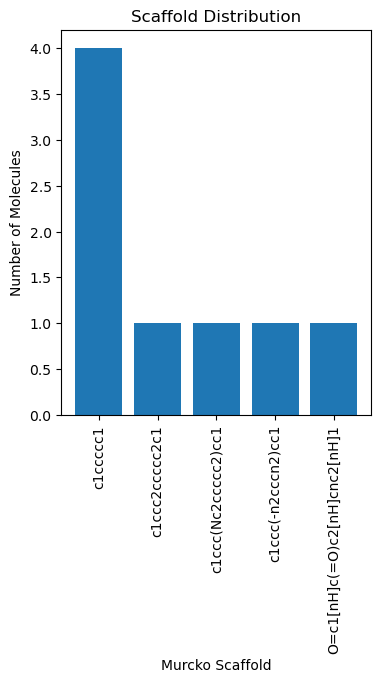

In [9]:
# Visualize Scaffold Distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(4,5))

plt.bar(
    scaffold_counts["Scaffold"],
    scaffold_counts["Frequency"]
)

plt.xticks(rotation=90)

plt.xlabel("Murcko Scaffold")

plt.ylabel("Number of Molecules")

plt.title("Scaffold Distribution")

plt.show()

In [10]:
# Calculate Scaffold Diversity

total_molecules = len(df)

unique_scaffolds = df["Scaffold"].nunique()

print("Total Molecules :", total_molecules)
print("Unique Scaffolds :", unique_scaffolds)
print("Scaffold Diversity :", unique_scaffolds/total_molecules)

Total Molecules : 8
Unique Scaffolds : 5
Scaffold Diversity : 0.625


### Interpretation

Our dataset contains 8 molecules but only 5 unique scaffolds.

This means several molecules belong to the same scaffold family.

For example, Aspirin, Paracetamol, and Ibuprofen all share a benzene-based scaffold despite having different biological activities.

Scaffold analysis helps medicinal chemists identify dominant scaffold families, evaluate library diversity, and prioritize scaffolds for further optimization.